In [1]:
# Local run — no Colab drive mount needed


In [2]:
# Dependencies already installed in .venv
# pip install transformers datasets seqeval torch pytorch-crf


In [3]:
#from transformers import BertTokenizer
import unicodedata
import os
import numpy as np
import json
from sklearn.model_selection import train_test_split

# Load dataset

In [4]:
# Use pre-split DNRTI dataset (19 entity types, 16 predicates)
# Split: stratified multi-label (Sechidis et al., 2011)
import json
from pathlib import Path

# Resolve paths relative to repo root, not notebook directory
repo_root = Path(__vsc_ipynb_file__).resolve().parent.parent if "__vsc_ipynb_file__" in dir() else Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

data_dir = repo_root / 'results' / 'finetuning' / 'data'

with open(data_dir / 'train_dnrti.json', 'r') as f:
    train_data = json.load(f)
with open(data_dir / 'val_dnrti.json', 'r') as f:
    val_data = json.load(f)
with open(data_dir / 'test_dnrti.json', 'r') as f:
    test_data = json.load(f)

print(f'Training data size: {len(train_data)}')
print(f'Validation data size: {len(val_data)}')
print(f'Test data size: {len(test_data)}')

Training data size: 6429
Validation data size: 722
Test data size: 707


In [5]:
# Data already pre-split — no need to write files
pass


In [6]:
train_data[0]

{'text': 'Kaspersky found the BlackOasis was exploiting a Adobe Flash Player zero-day vulnerability ( CVE-2016-4117 ) to remotely deliver the latest version of " FinSpy " malware , according to a new blog post published Monday .',
 'entities': [[0, 1, 'Kaspersky', 'SECTEAM'],
  [3, 4, 'BlackOasis', 'APT'],
  [7, 12, 'Adobe Flash Player zero-day vulnerability', 'VULNAME'],
  [13, 14, 'CVE-2016-4117', 'VULID'],
  [23, 24, 'FinSpy', 'MAL']],
 'relations': [['identifies', 1, 0],
  ['identifies', 2, 0],
  ['identifies', 3, 0],
  ['identifies', 4, 0],
  ['targets', 2, 1],
  ['targets', 3, 1],
  ['uses', 4, 1],
  ['associatedWith', 3, 2],
  ['targetedBy', 4, 2],
  ['targetedBy', 4, 3]],
 'ent_labels': ['B-SECTEAM',
  'O',
  'O',
  'B-APT',
  'O',
  'O',
  'O',
  'B-VULNAME',
  'I-VULNAME',
  'I-VULNAME',
  'I-VULNAME',
  'I-VULNAME',
  'O',
  'B-VULID',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-MAL',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O

# tokenization.py

In [7]:
# with open("tokenization.py", "w") as f:
#     f.write('''

from transformers import AutoTokenizer
import unicodedata


def _run_strip_accents(text):
    """Strips accents from a piece of text."""
    text = unicodedata.normalize("NFD", text)
    output = []
    for char in text:
        cat = unicodedata.category(char)
        if cat == "Mn":  # Mn means "Nonspacing Mark"
            continue
        output.append(char)
    return "".join(output)


class BERTTextEncoder(object):
    def __init__(self, model_name: str='bert-base-cased', do_lower_case: bool = True) -> None:
        # Load AutoTokenizer for the pre-trained model
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=do_lower_case)

        # Get special token IDs from the tokenizer
        self.bert_pad_id = self.tokenizer.pad_token_id
        self.bert_unk_id = self.tokenizer.unk_token_id
        self.bert_cls_id = self.tokenizer.cls_token_id
        self.bert_sep_id = self.tokenizer.sep_token_id
        self.bert_msk_id = self.tokenizer.mask_token_id

    def standardize_ids(self, ids):
        vocab_size = len(self.tokenizer.vocab)
        for i in range(len(ids)):
            if ids[i] == self.bert_pad_id:  # PAD
                ids[i] = 1 + vocab_size
            elif ids[i] == self.bert_unk_id:  # UNK
                ids[i] = 0
            elif ids[i] == self.bert_cls_id:  # CLS
                ids[i] = 3 + vocab_size
            elif ids[i] == self.bert_sep_id:  # SEP
                ids[i] = 5 + vocab_size
            elif ids[i] == self.bert_msk_id:  # MASK
                ids[i] = 2 + vocab_size
            elif ids[i] > self.bert_msk_id:  # VOCAB
                ids[i] -= self.bert_msk_id
        return ids

    def tokenize(self, text: str):
        """Tokenize input text using AutoTokenizer and return token data."""
        # Tokenize using AutoTokenizer with word-level and subword information
        encoding = self.tokenizer(text, return_offsets_mapping=True, is_split_into_words=False)

        tokens = encoding.tokens()  # Actual tokens
        token_ids = encoding['input_ids']  # Token IDs
        offset_mapping = encoding['offset_mapping']  # Character-level offsets for each token
        word_ids = encoding.word_ids()  # Word-level mapping is extracted here

        return tokens, token_ids, offset_mapping, word_ids

    def convert_tokens_to_ids(self, tokens):
        return self.tokenizer.convert_tokens_to_ids(tokens)

    def convert_ids_to_tokens(self, token_ids):
        """Converts token IDs back to tokens."""
        return self.tokenizer.convert_ids_to_tokens(token_ids)



  #''')

c:\CTI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# from transformers import AutoTokenizer

# # Initialize the tokenizer
# tokenizer = AutoTokenizer.from_pretrained('bert-base-cased')

# # # Save the tokenizer to a specific directory
# tokenizer.save_pretrained('./pretrain_weights/bert-base-cased/')

In [9]:
import os

bert_encoder = BERTTextEncoder(model_name='bert-base-cased')

projectName = 'je_bert_crf_dnrti_19types'

# --- NER labels: 19 DNRTI types x 2 (B/I) + null + O = 40 ---
neid2type = {
    0: 'null',
    1: 'O',
    2: 'B-APT',
    3: 'I-APT',
    4: 'B-MAL',
    5: 'I-MAL',
    6: 'B-TOOL',
    7: 'I-TOOL',
    8: 'B-ACT',
    9: 'I-ACT',
    10: 'B-IDTY',
    11: 'I-IDTY',
    12: 'B-LOC',
    13: 'I-LOC',
    14: 'B-TIME',
    15: 'I-TIME',
    16: 'B-FILE',
    17: 'I-FILE',
    18: 'B-SECTEAM',
    19: 'I-SECTEAM',
    20: 'B-OS',
    21: 'I-OS',
    22: 'B-VULID',
    23: 'I-VULID',
    24: 'B-VULNAME',
    25: 'I-VULNAME',
    26: 'B-HASH',
    27: 'I-HASH',
    28: 'B-DOM',
    29: 'I-DOM',
    30: 'B-ENCR',
    31: 'I-ENCR',
    32: 'B-IP',
    33: 'I-IP',
    34: 'B-URL',
    35: 'I-URL',
    36: 'B-PROT',
    37: 'I-PROT',
    38: 'B-EMAIL',
    39: 'I-EMAIL',
}

netype2id = {v: k for k, v in neid2type.items()}

# --- RE labels: 16 DNRTI predicates + null = 17 ---
reid2type = {
    0: 'null',
    1: 'noRelation',
    2: 'uses',
    3: 'usedBy',
    4: 'targets',
    5: 'targetedBy',
    6: 'affiliatedWith',
    7: 'associatedWith',
    8: 'identifies',
    9: 'identifiedBy',
    10: 'monitors',
    11: 'monitoredBy',
    12: 'hasLocation',
    13: 'hasAttackLocation',
    14: 'hasAttackTime',
    15: 'hasVulnerability',
    16: 'contains',
}

retype2id = {v: k for k, v in reid2type.items()}

print(f'NER labels: {len(neid2type)} ({len(neid2type)-2} BIO tags + null + O)')
print(f'RE labels:  {len(reid2type)} ({len(reid2type)-1} predicates + null)')


NER labels: 40 (38 BIO tags + null + O)
RE labels:  17 (16 predicates + null)


In [10]:
netype2id, neid2type

({'null': 0,
  'O': 1,
  'B-APT': 2,
  'I-APT': 3,
  'B-MAL': 4,
  'I-MAL': 5,
  'B-TOOL': 6,
  'I-TOOL': 7,
  'B-ACT': 8,
  'I-ACT': 9,
  'B-IDTY': 10,
  'I-IDTY': 11,
  'B-LOC': 12,
  'I-LOC': 13,
  'B-TIME': 14,
  'I-TIME': 15,
  'B-FILE': 16,
  'I-FILE': 17,
  'B-SECTEAM': 18,
  'I-SECTEAM': 19,
  'B-OS': 20,
  'I-OS': 21,
  'B-VULID': 22,
  'I-VULID': 23,
  'B-VULNAME': 24,
  'I-VULNAME': 25,
  'B-HASH': 26,
  'I-HASH': 27,
  'B-DOM': 28,
  'I-DOM': 29,
  'B-ENCR': 30,
  'I-ENCR': 31,
  'B-IP': 32,
  'I-IP': 33,
  'B-URL': 34,
  'I-URL': 35,
  'B-PROT': 36,
  'I-PROT': 37,
  'B-EMAIL': 38,
  'I-EMAIL': 39},
 {0: 'null',
  1: 'O',
  2: 'B-APT',
  3: 'I-APT',
  4: 'B-MAL',
  5: 'I-MAL',
  6: 'B-TOOL',
  7: 'I-TOOL',
  8: 'B-ACT',
  9: 'I-ACT',
  10: 'B-IDTY',
  11: 'I-IDTY',
  12: 'B-LOC',
  13: 'I-LOC',
  14: 'B-TIME',
  15: 'I-TIME',
  16: 'B-FILE',
  17: 'I-FILE',
  18: 'B-SECTEAM',
  19: 'I-SECTEAM',
  20: 'B-OS',
  21: 'I-OS',
  22: 'B-VULID',
  23: 'I-VULID',
  24: 'B-VULNAME'

In [11]:
def tokenize_and_align_labels(bert_encoder, text, entity_labels, label2id):
    # Preprocess text to handle abbreviations like "U.S."
    preprocessed_text = preprocess_text(text)

    # Tokenize the preprocessed text using BERTTextEncoder's tokenize function
    tokens, token_ids, offset_mapping, word_ids = bert_encoder.tokenize(preprocessed_text)

    aligned_labels = []
    prev_word_id = None

    # Align labels to tokens using the word_ids
    for idx, word_id in enumerate(word_ids):
        if word_id is None:
            aligned_labels.append(label2id["O"])  # Use "O" for special tokens like [CLS], [SEP]
        elif word_id == prev_word_id:
            aligned_labels.append(aligned_labels[-1])  # If same word split into subwords
        else:
            # Get the label corresponding to the original word index
            label = entity_labels[word_id] if word_id < len(entity_labels) else "O"
            aligned_labels.append(label2id.get(label, label2id["O"]))
        prev_word_id = word_id

    return tokens, aligned_labels, token_ids


In [12]:
import re
def preprocess_text(text):
    # Match abbreviations like "U.S.", "A.T.P.", etc., and ensure the final period is optional but removed
    abbreviation_pattern = re.compile(r'\b([A-Z])\.([A-Z])(?:\.([A-Z]))?\b\.')

    # Replace abbreviations by removing the periods
    modified_text = abbreviation_pattern.sub(lambda m: ''.join(m.groups('')), text)

    return modified_text

# Example usage
text = "In this same time frame, APT10 also targeted a U.S. law firm and an international apparel company."
modified_text = preprocess_text(text)
print(modified_text)


In this same time frame, APT10 also targeted a US law firm and an international apparel company.


In [13]:
# Quick sanity check with a sample sentence using DNRTI labels
text = "Since August 2018 , the Machete components have been delivered with an extra layer of obfuscation "
ent_labels = ['O', 'B-TIME', 'I-TIME', 'O', 'O', 'B-APT', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

# Tokenize and align the labels (netype2id already set in cell 10)
tokens, aligned_labels, tokenized_inputs = tokenize_and_align_labels(bert_encoder, text, ent_labels, netype2id)

labels = [neid2type[label] for label in aligned_labels]
for token, label in zip(tokens, labels):
    print(f'{token:15} {label}')

[CLS]           O
since           O
au              B-TIME
##gus           B-TIME
##t             B-TIME
2018            I-TIME
,               O
the             O
mac             B-APT
##he            B-APT
##te            B-APT
components      O
have            O
been            O
delivered       O
with            O
an              O
extra           O
layer           O
of              O
o               O
##b             O
##fu            O
##sca           O
##tion          O
[SEP]           O


In [14]:
def generate_mapped_entities(tokens, labels):
    maped_entities = []
    token_label_pairs = list(zip(tokens, labels))
    idx = 0

    while idx < len(token_label_pairs):
        token, label = token_label_pairs[idx]

        if label.startswith('B-'):  # Beginning of an entity
            start_idx = idx
            entity_type = label[2:]  # Get the entity type (e.g., 'HackOrg')

            # Move to the next token and continue until we no longer find subwords or I-* labels
            while (idx + 1 < len(token_label_pairs) and
                   (token_label_pairs[idx + 1][1].startswith('I-') or token_label_pairs[idx + 1][0].startswith('##'))):
                idx += 1

            # End of the entity (the current idx is the last token of the entity)
            end_idx = idx + 1
            maped_entities.append((start_idx, end_idx, entity_type))

        idx += 1

    return maped_entities


tokens, aligned_labels, tokenized_inputs = tokenize_and_align_labels(bert_encoder, text, ent_labels, netype2id)

labels = [neid2type[label] for label in aligned_labels]
maped_entities = generate_mapped_entities(tokens, labels)

# Print the mapped entities with start and end indexes
for entity in maped_entities:
    print(f"Entity: {entity[2]}, Start: {entity[0]}, End: {entity[1]}")


Entity: TIME, Start: 2, End: 6
Entity: APT, Start: 8, End: 11


In [15]:
def generate_pos_ids(batch_size: int, max_len: int) -> np.array:
    return np.repeat(np.arange(max_len, dtype=np.int32).reshape(1, -1), batch_size, 0)

In [16]:
data_path = './'  # not used — data loaded in cell 4
max_len = 150


In [17]:
import numpy as np
from tqdm import tqdm

def re_data_to_input_output(model_data, bert_encoder, max_len):
    input_ids, input_masks, input_entity_masks = [], [], []
    output_re_ids, output_ne_ids = [], []
    entity_type_ids = []

    for item in tqdm(model_data):
        text = item['text']
        entities = item['entities']
        relations = item['relations']
        ent_labels = item['ent_labels']

        tokens, aligned_labels, tokenized_inputs = tokenize_and_align_labels(bert_encoder, text, ent_labels, netype2id)

        labels = [neid2type[label] for label in aligned_labels]
        mapped_entities = generate_mapped_entities(tokens, labels)

        relation_map = {(start_entity_idx, end_entity_idx): relation_type
                        for relation_type, end_entity_idx, start_entity_idx in relations}

        netype_list = ['O'] * len(tokens)
        base_input_id = list(tokenized_inputs)  # save a clean copy

        for start_pos, end_pos, entity_type in mapped_entities:
            if end_pos - start_pos == 1:
                netype_list[start_pos] = "B-" + entity_type
            else:
                netype_list[start_pos] = "B-" + entity_type
                for tmp_pos in range(start_pos + 1, end_pos - 1):
                    netype_list[tmp_pos] = "I-" + entity_type
                netype_list[end_pos - 1] = "I-" + entity_type

        relation_entity_type_ids = []
        for start_entity_idx in range(len(entities)):
            for end_entity_idx in range(start_entity_idx + 1, len(entities)):
                remask = [0] * len(tokens)

                if start_entity_idx < len(mapped_entities) and mapped_entities[start_entity_idx]:
                    for tmp_pos in range(mapped_entities[start_entity_idx][0], mapped_entities[start_entity_idx][1]):
                        remask[tmp_pos] = 1

                if end_entity_idx < len(mapped_entities) and mapped_entities[end_entity_idx]:
                    for tmp_pos in range(mapped_entities[end_entity_idx][0], mapped_entities[end_entity_idx][1]):
                        remask[tmp_pos] = 1

                retype = relation_map.get((start_entity_idx, end_entity_idx), 'noRelation')
                start_entity_type = 'B-' + entities[start_entity_idx][3]
                end_entity_type = 'B-' + entities[end_entity_idx][3]
                start_entity_type_id = netype2id[start_entity_type]
                end_entity_type_id = netype2id[end_entity_type]

                # Fresh copies each iteration to avoid mutation
                input_id = list(base_input_id)
                input_mask = [1] * len(tokens)
                input_entity_mask = [0] + remask + [0]

                output_re_id = retype2id[retype]

                output_netype_list = ['null'] + netype_list + ['null']
                output_ne_id = [netype2id[item] for item in output_netype_list]

                # Truncate then pad to max_len
                input_id = input_id[:max_len]
                input_mask = input_mask[:max_len]
                input_entity_mask = input_entity_mask[:max_len]
                output_ne_id = output_ne_id[:max_len]

                input_id += [0] * (max_len - len(input_id))
                input_mask += [0] * (max_len - len(input_mask))
                input_entity_mask += [0] * (max_len - len(input_entity_mask))
                output_ne_id += [0] * (max_len - len(output_ne_id))

                input_ids.append(input_id)
                input_masks.append(input_mask)
                input_entity_masks.append(input_entity_mask)
                output_re_ids.append(output_re_id)
                output_ne_ids.append(output_ne_id)
                relation_entity_type_ids.append([start_entity_type_id, end_entity_type_id])
        entity_type_ids.extend(relation_entity_type_ids)

    input_ids = np.array(input_ids, dtype=np.int32)
    input_masks = np.array(input_masks, dtype=np.int32)
    input_entity_masks = np.array(input_entity_masks, dtype=np.int32)
    entity_type_ids = np.array(entity_type_ids, dtype=np.int32)
    output_re_ids = np.array(output_re_ids, dtype=np.int32)
    output_ne_ids = np.array(output_ne_ids, dtype=np.int32)

    pos = generate_pos_ids(len(input_ids), max_len)
    input_type_ids = np.zeros((len(input_ids), max_len), dtype=np.int32)

    y_train = [output_ne_ids, output_re_ids]
    return [input_ids, input_masks, input_entity_masks, entity_type_ids], y_train

In [18]:
# Data already loaded from cell 4
print(f'Train: {len(train_data)}, Dev: {len(val_data)}, Test: {len(test_data)}')

x_train, y_train = re_data_to_input_output(train_data, bert_encoder, max_len)
x_val, y_val = re_data_to_input_output(val_data, bert_encoder, max_len)
x_test, y_test = re_data_to_input_output(test_data, bert_encoder, max_len)


Train: 6429, Dev: 722, Test: 707


100%|██████████| 707/707 [00:00<00:00, 7623.13it/s]


In [19]:
netype2id

{'null': 0,
 'O': 1,
 'B-APT': 2,
 'I-APT': 3,
 'B-MAL': 4,
 'I-MAL': 5,
 'B-TOOL': 6,
 'I-TOOL': 7,
 'B-ACT': 8,
 'I-ACT': 9,
 'B-IDTY': 10,
 'I-IDTY': 11,
 'B-LOC': 12,
 'I-LOC': 13,
 'B-TIME': 14,
 'I-TIME': 15,
 'B-FILE': 16,
 'I-FILE': 17,
 'B-SECTEAM': 18,
 'I-SECTEAM': 19,
 'B-OS': 20,
 'I-OS': 21,
 'B-VULID': 22,
 'I-VULID': 23,
 'B-VULNAME': 24,
 'I-VULNAME': 25,
 'B-HASH': 26,
 'I-HASH': 27,
 'B-DOM': 28,
 'I-DOM': 29,
 'B-ENCR': 30,
 'I-ENCR': 31,
 'B-IP': 32,
 'I-IP': 33,
 'B-URL': 34,
 'I-URL': 35,
 'B-PROT': 36,
 'I-PROT': 37,
 'B-EMAIL': 38,
 'I-EMAIL': 39}

In [20]:
x_dev, y_dev = re_data_to_input_output(val_data, bert_encoder, max_len)
x_test, y_test = re_data_to_input_output(test_data, bert_encoder, max_len)

# x_dev, y_dev = re_data_to_input_output(val_data_subset, bert_encoder, max_len)
# x_test, y_test = re_data_to_input_output(test_data_subset, bert_encoder, max_len)

100%|██████████| 707/707 [00:00<00:00, 7608.18it/s]


In [21]:
#2 + 'p'

In [22]:
y_train

[array([[ 0,  1, 18, ...,  0,  0,  0],
        [ 0,  1, 18, ...,  0,  0,  0],
        [ 0,  1, 18, ...,  0,  0,  0],
        ...,
        [ 0,  1,  4, ...,  0,  0,  0],
        [ 0,  1,  1, ...,  0,  0,  0],
        [ 0,  1,  1, ...,  0,  0,  0]], shape=(51804, 150), dtype=int32),
 array([ 8,  8,  8, ..., 14,  2,  2], shape=(51804,), dtype=int32)]

Relation label distribution: {np.int32(1): np.int64(19838), np.int32(2): np.int64(7931), np.int32(3): np.int64(2375), np.int32(4): np.int64(5343), np.int32(5): np.int64(2586), np.int32(6): np.int64(962), np.int32(7): np.int64(3183), np.int32(8): np.int64(1748), np.int32(9): np.int64(365), np.int32(10): np.int64(655), np.int32(11): np.int64(187), np.int32(12): np.int64(1610), np.int32(13): np.int64(2764), np.int32(14): np.int64(1096), np.int32(15): np.int64(831), np.int32(16): np.int64(330)}


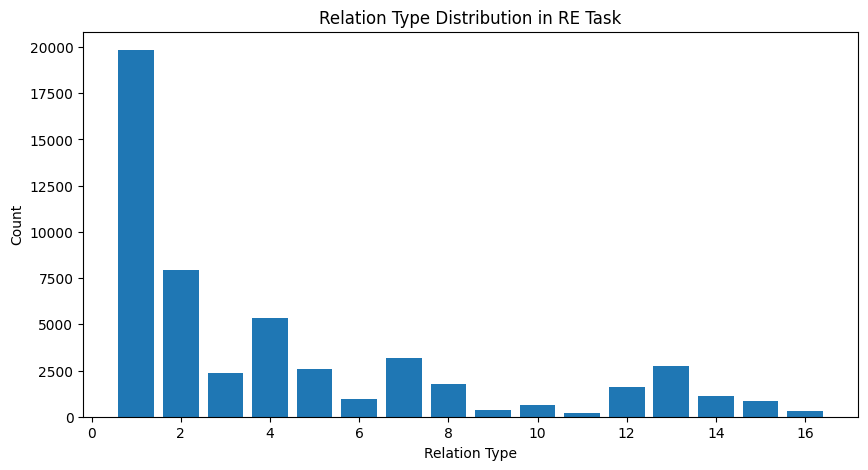

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Get RE labels from y_train
re_labels = y_train[1]

# Count the occurrences of each relation type
unique, counts = np.unique(re_labels, return_counts=True)
label_distribution = dict(zip(unique, counts))

# Display the distribution of relation types
print("Relation label distribution:", label_distribution)

# Plot the distribution of relation types
plt.figure(figsize=(10, 5))
plt.bar(label_distribution.keys(), label_distribution.values())
plt.xlabel('Relation Type')
plt.ylabel('Count')
plt.title('Relation Type Distribution in RE Task')
plt.show()


In [24]:
from collections import Counter
import numpy as np

# Current RE class distribution
re_labels_flat = y_train[1].tolist() if hasattr(y_train[1], 'tolist') else list(y_train[1])
re_class_counts = Counter(re_labels_flat)
print('Original RE class distribution:')
for cls_id, count in sorted(re_class_counts.items(), key=lambda x: -x[1]):
    label = reid2type.get(cls_id, f'unk_{cls_id}')
    print(f'  {label:20s} (id={cls_id}): {count}')

# Auto-balance: oversample minority classes to median count
counts = [c for cid, c in re_class_counts.items() if cid != 0]
median_count = int(np.median(counts))
target_min = max(median_count, 2000)

target_oversample = {}
for cls_id, count in re_class_counts.items():
    if cls_id == 0:
        continue
    target_oversample[cls_id] = max(count, target_min)

# Cap noRelation
norel_id = retype2id.get('noRelation', 1)
if norel_id in target_oversample:
    target_oversample[norel_id] = min(
        target_oversample[norel_id],
        max(target_min * 3, re_class_counts.get(norel_id, 0))
    )

print(f'\nTarget oversample (min={target_min}):')
for cls_id, target in sorted(target_oversample.items()):
    label = reid2type.get(cls_id, f'unk_{cls_id}')
    print(f'  {label:20s}: {re_class_counts.get(cls_id, 0)} -> {target}')

def oversample_classes(x_data, y_data, targets):
    input_ids, attn_mask, ent_mask, ent_type_ids = x_data
    ner_labels, re_labels = y_data
    input_ids = input_ids.tolist()
    attn_mask = attn_mask.tolist()
    ent_mask = ent_mask.tolist()
    ent_type_ids = ent_type_ids.tolist()
    ner_labels = ner_labels.tolist()
    re_labels = re_labels.tolist()

    by_class = {}
    for i, lbl in enumerate(re_labels):
        v = lbl if isinstance(lbl, int) else int(np.argmax(lbl))
        by_class.setdefault(v, []).append(i)

    out = {k: list(v) for k, v in zip(
        ['iid','am','em','et','nl','rl'],
        [input_ids, attn_mask, ent_mask, ent_type_ids, ner_labels, re_labels]
    )}

    for cls, tgt in targets.items():
        if cls not in by_class:
            continue
        cur = len(by_class[cls])
        if cur >= tgt:
            continue
        extra = np.random.choice(by_class[cls], size=tgt - cur, replace=True)
        for idx in extra:
            out['iid'].append(input_ids[idx])
            out['am'].append(attn_mask[idx])
            out['em'].append(ent_mask[idx])
            out['et'].append(ent_type_ids[idx])
            out['nl'].append(ner_labels[idx])
            out['rl'].append(re_labels[idx])

    return (
        (np.array(out['iid']), np.array(out['am']),
         np.array(out['em']), np.array(out['et'])),
        (np.array(out['nl']), np.array(out['rl']))
    )

x_train_resampled, y_train_resampled = oversample_classes(
    x_train, y_train, target_oversample
)
print(f'\nAfter resampling: {len(x_train_resampled[0])} samples '
      f'(was {len(x_train[0])})')


Original RE class distribution:
  noRelation           (id=1): 19838
  uses                 (id=2): 7931
  targets              (id=4): 5343
  associatedWith       (id=7): 3183
  hasAttackLocation    (id=13): 2764
  targetedBy           (id=5): 2586
  usedBy               (id=3): 2375
  identifies           (id=8): 1748
  hasLocation          (id=12): 1610
  hasAttackTime        (id=14): 1096
  affiliatedWith       (id=6): 962
  hasVulnerability     (id=15): 831
  monitors             (id=10): 655
  identifiedBy         (id=9): 365
  contains             (id=16): 330
  monitoredBy          (id=11): 187

Target oversample (min=2000):
  noRelation          : 19838 -> 19838
  uses                : 7931 -> 7931
  usedBy              : 2375 -> 2375
  targets             : 5343 -> 5343
  targetedBy          : 2586 -> 2586
  affiliatedWith      : 962 -> 2000
  associatedWith      : 3183 -> 3183
  identifies          : 1748 -> 2000
  identifiedBy        : 365 -> 2000
  monitors            : 65

In [25]:
import numpy as np
from collections import Counter

# y_train_resampled[1] should be the RE labels part of y_train
re_labels_resampled = np.array(y_train_resampled[1])

# Set the target count for undersampling "noRelation" (Class 1)
no_relation_target_count = 8000  # You can change this to 7000 or another value as needed

# Get the indices for 'noRelation' class (class 1)
no_relation_indices = np.where(re_labels_resampled == 1)[0]

# Randomly sample the required number of "noRelation" samples
undersample_indices = np.random.choice(no_relation_indices, no_relation_target_count, replace=False)

# Get the indices for the rest of the classes (non-"noRelation")
non_no_relation_indices = np.where(re_labels_resampled != 1)[0]

# Combine the undersampled "noRelation" indices with the non-"noRelation" indices
final_indices = np.concatenate([undersample_indices, non_no_relation_indices])

# Use these indices to filter x_train_resampled and y_train_resampled
x_train_final = [x[final_indices] for x in x_train_resampled]  # Filter each element in x_train_resampled
y_train_final = [
    y_train_resampled[0][final_indices],  # Filter NER labels (part of y_train_resampled)
    re_labels_resampled[final_indices]    # Filter RE labels
]

# Verify the new distribution after undersampling
new_class_distribution = Counter(y_train_final[1])  # Check RE label distribution
print(f"New class distribution after undersampling: {new_class_distribution}")


New class distribution after undersampling: Counter({np.int64(1): 8000, np.int64(2): 7931, np.int64(4): 5343, np.int64(7): 3183, np.int64(13): 2764, np.int64(5): 2586, np.int64(3): 2375, np.int64(8): 2000, np.int64(15): 2000, np.int64(12): 2000, np.int64(10): 2000, np.int64(9): 2000, np.int64(6): 2000, np.int64(14): 2000, np.int64(11): 2000, np.int64(16): 2000})


In [26]:
x_train_final

[array([[  101, 19450,  1606, ...,     0,     0,     0],
        [  101,  1229,  1103, ...,     0,     0,     0],
        [  101,  1170,  3254, ...,     0,     0,     0],
        ...,
        [  101,  1103,  9133, ...,     0,     0,     0],
        [  101,  1103, 10632, ...,     0,     0,     0],
        [  101,  1649,   117, ...,     0,     0,     0]],
       shape=(50182, 150)),
 array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(50182, 150)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(50182, 150)),
 array([[10, 10],
        [20, 20],
        [10, 10],
        ...,
        [16,  4],
        [16,  4],
        [16,  4]], shape=(50182, 2))]

Relation label distribution: {np.int64(1): np.int64(8000), np.int64(2): np.int64(7931), np.int64(3): np.int64(2375), np.int64(4): np.int64(5343), np.int64(5): np.int64(2586), np.int64(6): np.int64(2000), np.int64(7): np.int64(3183), np.int64(8): np.int64(2000), np.int64(9): np.int64(2000), np.int64(10): np.int64(2000), np.int64(11): np.int64(2000), np.int64(12): np.int64(2000), np.int64(13): np.int64(2764), np.int64(14): np.int64(2000), np.int64(15): np.int64(2000), np.int64(16): np.int64(2000)}


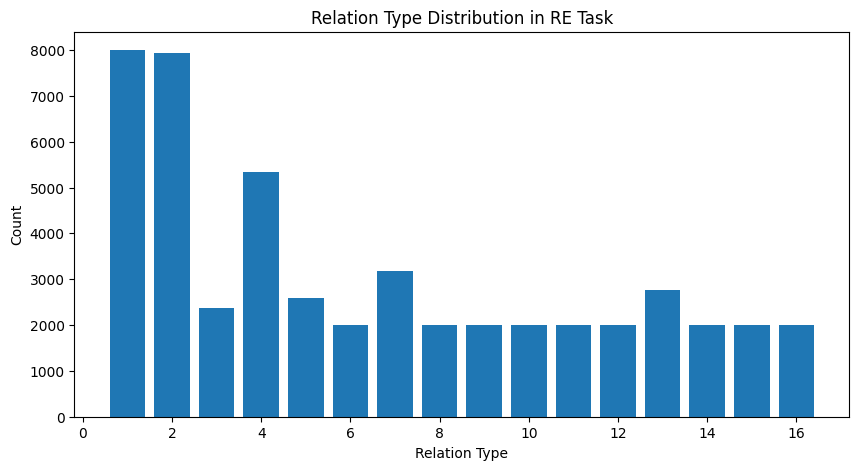

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Get RE labels from y_train
re_labels = y_train_final[1]

# Count the occurrences of each relation type
unique, counts = np.unique(re_labels, return_counts=True)
label_distribution = dict(zip(unique, counts))

# Display the distribution of relation types
print("Relation label distribution:", label_distribution)

# Plot the distribution of relation types
plt.figure(figsize=(10, 5))
plt.bar(label_distribution.keys(), label_distribution.values())
plt.xlabel('Relation Type')
plt.ylabel('Count')
plt.title('Relation Type Distribution in RE Task')
plt.show()


In [28]:

# Verify the shapes of x_train
print(f"x_train shapes: {[x.shape for x in x_train]}")  # Should show shapes of each input array

# Verify the shapes of y_train
print(f"y_train shapes: {[y.shape for y in y_train]}")  # Should show shapes of NER and RE outputs

# Ensure the first element in y_train has the correct shape
print(f"First element of y_train (NER): {y_train[0].shape}")  # Should be (87, 100, num_classes)
print(f"Second element of y_train (RE): {y_train[1].shape}")  # Should be (87,)


x_train shapes: [(51804, 150), (51804, 150), (51804, 150), (51804, 2)]
y_train shapes: [(51804, 150), (51804,)]
First element of y_train (NER): (51804, 150)
Second element of y_train (RE): (51804,)


In [29]:
# Verify the shapes of x_train
print(f"x_train shapes: {[x.shape for x in x_train_final]}")  # Should show shapes of each input array

# Verify the shapes of y_train
print(f"y_train shapes: {[y.shape for y in y_train_final]}")  # Should show shapes of NER and RE outputs

# Ensure the first element in y_train has the correct shape
print(f"First element of y_train (NER): {y_train_final[0].shape}")  # Should be (87, 100, num_classes)
print(f"Second element of y_train (RE): {y_train_final[1].shape}")  # Should be (87,)

x_train shapes: [(50182, 150), (50182, 150), (50182, 150), (50182, 2)]
y_train shapes: [(50182, 150), (50182,)]
First element of y_train (NER): (50182, 150)
Second element of y_train (RE): (50182,)


In [30]:
x_train[0][1]

array([  101, 24181, 20623,  4969,  1276,  1103,  1602, 12985,  4863,
        1108, 19685,  1158,   170,  8050, 21367,  6746,  1591,  6756,
         118,  1285, 20727,   113,   172,  2707,   118,  1446,   118,
        3746, 16770,   114,  1106, 21699,  7852,  1103,  6270,  1683,
        1104,   107, 20823,  5005,   107, 12477,  1233,  7109,   117,
        2452,  1106,   170,  1207, 10679,  2112,  1502, 19863,  6194,
         119,   102,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,

In [31]:
x_train[3][1]

array([18, 24], dtype=int32)

In [32]:
# Select a sample to display (for example, the first sample)
sample_idx = 1

# Display tokenized input IDs and masks
print(f"Input tokens (input_ids) for sample {sample_idx}:")
print(x_train[0][sample_idx])  # Token IDs
print("\nInput attention mask (input_masks) for sample:")
print(x_train[1][sample_idx])  # Attention Mask
print("\nEntity mask (input_entity_masks) for sample:")
print(x_train[2][sample_idx])  # Entity Mask
print("\nEntity type IDs (entity_type_ids) for sample:")
print(x_train[3][sample_idx])  # Entity type IDs

# Display NER labels
print("\nNER labels (output_ne_ids) for sample:")
print(y_train[0][sample_idx])  # NER labels

# Display RE labels (output_re_ids)
print("\nRE labels (output_re_ids) for sample:")
print(y_train[1][sample_idx])  # RE labels

# You can also display the tokenized input as words by converting the token IDs back to tokens using the tokenizer:
print("\nTokenized sentence:")
tokens = bert_encoder.convert_ids_to_tokens(x_train[0][sample_idx])
print(tokens)


Input tokens (input_ids) for sample 1:
[  101 24181 20623  4969  1276  1103  1602 12985  4863  1108 19685  1158
   170  8050 21367  6746  1591  6756   118  1285 20727   113   172  2707
   118  1446   118  3746 16770   114  1106 21699  7852  1103  6270  1683
  1104   107 20823  5005   107 12477  1233  7109   117  2452  1106   170
  1207 10679  2112  1502 19863  6194   119   102     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0]

Input attention mask (input_masks) for sample:

In [33]:
# pytorch-crf already installed
import torchcrf


In [34]:
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer
import torch
import torch.nn as nn
import torchcrf
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

W0313 21:56:37.532000 1824 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [35]:


class JointExtractionModel(nn.Module):
    def __init__(self, bert_model, num_ner_labels, num_re_labels, entity_type_vocab_size):
        super(JointExtractionModel, self).__init__()
        self.bert = bert_model

        # Linear projection layer for NER task
        self.ner_classifier = nn.Linear(bert_model.config.hidden_size, num_ner_labels)

        # Dimentionality reduction
        self.re_dim_reduction = nn.Linear(bert_model.config.hidden_size * 3, bert_model.config.hidden_size) #[input_dim, output_dim]=[768x3, 768]

        # RE classification layer
        self.re_classifier = nn.Linear(bert_model.config.hidden_size, num_re_labels)

        # Entity type embedding
        self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, bert_model.config.hidden_size)

        # CRF Layer for NER
        self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

    def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
        # BERT output
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs[0]  # (batch_size, seq_length, hidden_size)

        # Entity type embedding
        entity_type_embedded = self.entity_type_embedding(entity_type_ids)

        # NER classification (for each token)
        ner_logits = self.ner_classifier(sequence_output)  # (batch_size, seq_length, num_ner_labels)

        # RE classification (based on the entity pairs)
        entity_pair_representation = self.pool_entity_pairs(sequence_output, entity_mask, entity_type_embedded)

        # Reduce the dimensionality of the entity pair representation
        # entity_pair_representation shape should be (batch_size, hidden_size * 3)
        reduced_entity_representation = self.re_dim_reduction(entity_pair_representation)
        #print( f"Reduced Entity Representation Shape: {reduced_entity_representation.shape}")

        # Pass the reduced representation to the RE classifier
        re_logits = self.re_classifier(reduced_entity_representation)

        # If ner_labels are provided, compute the CRF loss for NER task
        if ner_labels is not None:
            ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
        else:
            ner_loss = None

        return ner_logits, re_logits, ner_loss

    def pool_entity_pairs(self, sequence_output, entity_mask, entity_type_embeddings):
        """
        Pool the entity pair representation from the sequence_output using the entity_mask and entity_type_embeddings.
        """
        # Apply entity mask to sequence_output to select the entity tokens
        entity_mask = entity_mask.unsqueeze(-1)  # Shape: (batch_size, seq_length, 1)
        masked_output = sequence_output * entity_mask  # Shape: (batch_size, seq_length, hidden_size)

        # Sum the masked tokens to pool the entity representation
        entity_representation = masked_output.sum(dim=1)  # Shape: (batch_size, hidden_size)
        pooled_entity_pairs = torch.cat([entity_representation, entity_type_embeddings.view(entity_type_embeddings.size(0), -1)], dim=-1)

        return pooled_entity_pairs

    def decode_ner(self, ner_logits, attention_mask):
        # Use the CRF layer to decode the best path (predicted NER tags)
        return self.crf.decode(ner_logits, mask=attention_mask.bool())




**Entity Type Only**

In [36]:


# class JointExtractionModel(nn.Module):
#     def __init__(self, bert_model, num_ner_labels, num_re_labels, entity_type_vocab_size, use_entity_mask=False):
#         super(JointExtractionModel, self).__init__()
#         self.bert = bert_model
#         self.use_entity_mask = use_entity_mask

#         self.ner_classifier = nn.Linear(bert_model.config.hidden_size, num_ner_labels)

#         input_dim = bert_model.config.hidden_size * 3 if use_entity_mask else bert_model.config.hidden_size * 2
#         self.re_dim_reduction = nn.Linear(input_dim, bert_model.config.hidden_size)
#         self.re_classifier = nn.Linear(bert_model.config.hidden_size, num_re_labels)

#         self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, bert_model.config.hidden_size)
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)


#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask=None, ner_labels=None, re_labels=None):
#         outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = outputs[0]

#         entity_type_embedded = self.entity_type_embedding(entity_type_ids)
#         ner_logits = self.ner_classifier(sequence_output)

#         # Depending on the mode, use or ignore entity_mask
#         if self.use_entity_mask:
#             entity_pair_representation = self.pool_entity_pairs(sequence_output, entity_mask, entity_type_embedded)
#         else:
#             entity_pair_representation = self.pool_entity_pairs(sequence_output, None, entity_type_embedded)

#         reduced_entity_representation = self.re_dim_reduction(entity_pair_representation)
#         re_logits = self.re_classifier(reduced_entity_representation)

#         ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean') if ner_labels is not None else None

#         return ner_logits, re_logits, ner_loss


#     def pool_entity_pairs(self, sequence_output, entity_mask, entity_type_embeddings):
#         if self.use_entity_mask:
#             entity_mask = entity_mask.unsqueeze(-1)  # (batch_size, seq_length, 1)
#             masked_output = sequence_output * entity_mask
#             entity_representation = masked_output.sum(dim=1)  # (batch_size, hidden_size)
#             pooled = torch.cat([entity_representation, entity_type_embeddings.view(entity_type_embeddings.size(0), -1)], dim=-1)
#         else:
#             # Use only entity_type_embeddings, flatten to (batch_size, hidden_size * 2)
#             pooled = entity_type_embeddings.view(entity_type_embeddings.size(0), -1)

#         return pooled


#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())




**Entity Mask Only**

In [37]:
# class JointExtractionModel(nn.Module):
#     def __init__(self, bert_model, num_ner_labels, num_re_labels, entity_type_vocab_size):
#         super(JointExtractionModel, self).__init__()
#         self.bert = bert_model

#         # Linear projection layer for NER task
#         self.ner_classifier = nn.Linear(bert_model.config.hidden_size, num_ner_labels)

#         # Dimentionality reduction
#        # self.re_dim_reduction = nn.Linear(bert_model.config.hidden_size * 3, bert_model.config.hidden_size) #[input_dim, output_dim]=[768x3, 768]
#         self.re_dim_reduction = nn.Linear(bert_model.config.hidden_size, bert_model.config.hidden_size)


#         # RE classification layer
#         self.re_classifier = nn.Linear(bert_model.config.hidden_size, num_re_labels)

#         # Entity type embedding
#         self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, bert_model.config.hidden_size)

#         # CRF Layer for NER
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
#         # BERT output
#         outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = outputs[0]  # (batch_size, seq_length, hidden_size)

#         # Entity type embedding
#         entity_type_embedded = self.entity_type_embedding(entity_type_ids)

#         # NER classification (for each token)
#         ner_logits = self.ner_classifier(sequence_output)  # (batch_size, seq_length, num_ner_labels)

#         # RE classification (based on the entity pairs)
#         #entity_pair_representation = self.pool_entity_pairs(sequence_output, entity_mask, entity_type_embedded)
#         entity_pair_representation = self.pool_entity_pairs(sequence_output, entity_mask)


#         # Reduce the dimensionality of the entity pair representation
#         # entity_pair_representation shape should be (batch_size, hidden_size * 3)
#         reduced_entity_representation = self.re_dim_reduction(entity_pair_representation)

#         #print( f"Reduced Entity Representation Shape: {reduced_entity_representation.shape}")

#         # Pass the reduced representation to the RE classifier
#         re_logits = self.re_classifier(reduced_entity_representation)

#         # If ner_labels are provided, compute the CRF loss for NER task
#         if ner_labels is not None:
#             ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
#         else:
#             ner_loss = None

#         return ner_logits, re_logits, ner_loss

#     def pool_entity_pairs(self, sequence_output, entity_mask, entity_type_embeddings=None):
#         """
#         Pool the entity pair representation from the sequence_output using only the entity_mask.
#         """
#         entity_mask = entity_mask.unsqueeze(-1)  # (batch_size, seq_length, 1)
#         masked_output = sequence_output * entity_mask  # (batch_size, seq_length, hidden_size)

#         # Pool by summing (or use mean if preferred)
#         entity_representation = masked_output.sum(dim=1)  # (batch_size, hidden_size)

#         return entity_representation  # Return without concatenating with entity_type_embeddings


#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())

# Without Pooling

In [38]:
# class JointExtractionModel(nn.Module):
#     def __init__(self, bert_model, num_ner_labels, num_re_labels, entity_type_vocab_size):
#         super(JointExtractionModel, self).__init__()
#         self.bert = bert_model

#         # Linear projection layer for NER task
#         self.ner_classifier = nn.Linear(bert_model.config.hidden_size, num_ner_labels)

#         # RE classification layer
#         self.re_classifier = nn.Linear(bert_model.config.hidden_size, num_re_labels)

#         # CRF Layer for NER
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
#         # BERT output
#         outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = outputs[0]  # (batch_size, seq_length, hidden_size)

#         # NER classification (for each token)
#         ner_logits = self.ner_classifier(sequence_output)  # (batch_size, seq_length, num_ner_labels)

#         # RE classification using the mean of the BERT output
#         re_logits = self.re_classifier(sequence_output.mean(dim=1))  # (batch_size, num_re_labels)
#         #re_logits = self.re_classifier(sequence_output)

#         # If ner_labels are provided, compute the CRF loss for NER task
#         if ner_labels is not None:
#             ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
#         else:
#             ner_loss = None

#         return ner_logits, re_logits, ner_loss

#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())


In [39]:
class JointExtractionDataset(Dataset):
    def __init__(self, x_train, y_train):
        # x_train arrays
        self.input_ids = x_train[0]
        self.input_masks = x_train[1]
        self.input_entity_masks = x_train[2]
        self.entity_type_ids = x_train[3]  # New entity_type_ids

        # y_train arrays
        self.ner_labels = y_train[0]
        self.re_labels = y_train[1]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.input_masks[idx], dtype=torch.long),
            'entity_mask': torch.tensor(self.input_entity_masks[idx], dtype=torch.long),
            'entity_type_ids': torch.tensor(self.entity_type_ids[idx], dtype=torch.long),  # Entity type IDs
            'ner_labels': torch.tensor(self.ner_labels[idx], dtype=torch.long),  # NER class indices
            're_labels': torch.tensor(self.re_labels[idx], dtype=torch.long)  # RE class indices (not one-hot)
        }


In [40]:
#train_dataset = JointExtractionDataset(x_train, y_train)
train_dataset = JointExtractionDataset(x_train_final, y_train_final)
val_dataset = JointExtractionDataset(x_dev, y_dev)
test_dataset = JointExtractionDataset(x_test, y_test)

# Create dataloader
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [41]:
sample = train_dataset[3]
print("Input IDs:", sample['input_ids'])
print("Attention Mask:", sample['attention_mask'])
print("Entity Mask:", sample['entity_mask'])
print("Entity Type IDs:", sample['entity_type_ids'])
print("NER Labels:", sample['ner_labels'])
print("RE Labels:", sample['re_labels'])

Input IDs: tensor([  101,  1103,  5795,  4487, 12559,  1200,  1372,  1144, 10594,  5256,
         1506,  2967, 18879,  1107,  1241,  1103,  1470,  1105,  2029,  4291,
         1259,  1433,  4300,   117,  9712, 16531, 23434,   117,  1103,  2949,
         1105,  3245,  2380,   117,  1844,  6425,   117,  1764, 19874,  1105,
        10254,   119,   102,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,    

In [42]:
# Set device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")

In [ ]:
import torch
import numpy as np
import random
from transformers import BertModel

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Initialize the BERT model from Hugging Face
bert_model = BertModel.from_pretrained('bert-base-cased')

# Define the number of labels for NER and RE tasks
num_ner_labels = len(neid2type)  # 40: 19 types x 2 (B/I) + null + O
num_re_labels = len(reid2type)   # 17: 16 predicates + null

entity_type_vocab_size = num_ner_labels

# Initialize the JointExtractionModel with the entity_type_vocab_size
model = JointExtractionModel(bert_model, num_ner_labels, num_re_labels, entity_type_vocab_size)

# Move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Model on {device}, NER labels: {num_ner_labels}, RE labels: {num_re_labels}, seed: {SEED}")

In [44]:

# Generate some dummy data to test the model
batch_size = 2
seq_length = 150

# Ensure that input_ids are within the BERT vocabulary range (typically < 30,000)
dummy_input_ids = torch.randint(0, 30500, (batch_size, seq_length)).clamp(0, bert_model.config.vocab_size - 1).to(device)

dummy_attention_mask = torch.ones((batch_size, seq_length)).to(device)
dummy_entity_mask = torch.zeros((batch_size, seq_length)).to(device)

# Adjust entity type IDs to fall within the valid range
dummy_entity_type_ids = torch.randint(0, num_ner_labels, (batch_size, 2)).to(device)

dummy_ner_labels = torch.randint(0, num_ner_labels, (batch_size, seq_length)).to(device)
dummy_re_labels = torch.randint(0, num_re_labels, (batch_size,)).to(device)

# Optionally print out to verify the range
print(f"Max input ID: {dummy_input_ids.max().item()}")
print(f"Min input ID: {dummy_input_ids.min().item()}")


dummy_entity_type_ids = torch.clamp(dummy_entity_type_ids, max=entity_type_vocab_size - 1)

ner_logits, re_logits, ner_loss = model(
    input_ids=dummy_input_ids,
    attention_mask=dummy_attention_mask,
    entity_type_ids=dummy_entity_type_ids,
    entity_mask=dummy_entity_mask,
    ner_labels=dummy_ner_labels,
    re_labels=dummy_re_labels
)

# Print the output shapes and loss
print("NER logits shape:", ner_logits.shape)
print("RE logits shape:", re_logits.shape)
print("NER loss:", ner_loss)

Max input ID: 28995
Min input ID: 2
NER logits shape: torch.Size([2, 150, 40])
RE logits shape: torch.Size([2, 17])
NER loss: tensor(556.9581, device='cuda:0', grad_fn=<NegBackward0>)


In [45]:
# Loss functions
ner_loss_function = None  # CRF loss is already calculated inside the model
re_loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [46]:
# def validate_model(model, val_dataloader):
#     model.eval()  # Set the model to evaluation mode
#     total_ner_loss = 0
#     total_re_loss = 0
#     correct_re_predictions = 0
#     total_re_samples = 0

#     with torch.no_grad():  # Disable gradient calculation during validation
#         for batch in val_dataloader:
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             entity_mask = batch['entity_mask'].to(device)
#             entity_type_ids = batch['entity_type_ids'].to(device)
#             ner_labels = batch['ner_labels'].to(device)
#             re_labels = batch['re_labels'].to(device)

#             # Forward pass
#             ner_logits, re_logits, ner_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels)

#             # Compute RE loss
#             re_loss = re_loss_fn(re_logits, re_labels)

#             # Track losses and accuracy
#             total_ner_loss += ner_loss.item()
#             total_re_loss += re_loss.item()

#             _, predicted_re_labels = torch.max(re_logits, 1)
#             correct_re_predictions += (predicted_re_labels == re_labels).sum().item()
#             total_re_samples += re_labels.size(0)

#     # Calculate validation metrics
#     avg_ner_loss = total_ner_loss / len(val_dataloader)
#     avg_re_loss = total_re_loss / len(val_dataloader)
#     re_accuracy = correct_re_predictions / total_re_samples

#     return avg_ner_loss, avg_re_loss, re_accuracy

def validate_model(model, val_dataloader):
    model.eval()  # Set model to evaluation mode
    total_ner_loss = 0
    total_re_loss = 0
    correct_re_predictions = 0
    correct_ner_predictions = 0
    total_re_samples = 0
    total_ner_tokens = 0

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Forward pass
            ner_logits, re_logits, ner_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels)
            #ner_logits, re_logits, ner_loss, re_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels, re_labels)

            # Compute RE loss
            re_loss = re_loss_fn(re_logits, re_labels)

            # Track the NER and RE losses
            total_ner_loss += ner_loss.item()
            total_re_loss += re_loss.item()

            # Calculate RE accuracy
            _, predicted_re_labels = torch.max(re_logits, 1)
            correct_re_predictions += (predicted_re_labels == re_labels).sum().item()
            total_re_samples += re_labels.size(0)

            # Calculate NER accuracy
            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)
            for i in range(len(predicted_ner_labels)):
                pred_labels_tensor = torch.tensor(predicted_ner_labels[i], dtype=torch.long).to(device)
                true_labels_tensor = ner_labels[i][:len(pred_labels_tensor)]
                correct_ner_predictions += (pred_labels_tensor == true_labels_tensor).sum().item()
                total_ner_tokens += len(pred_labels_tensor)

    # Calculate average losses and accuracies
    avg_ner_loss = total_ner_loss / len(val_dataloader)
    avg_re_loss = total_re_loss / len(val_dataloader)
    re_accuracy = correct_re_predictions / total_re_samples
    ner_accuracy = correct_ner_predictions / total_ner_tokens

    return avg_ner_loss, avg_re_loss, re_accuracy, ner_accuracy


In [47]:
alpha=1.7
beta=0.3

# (α,β)∈{(1.2,0.8),(1.4,0.6),(1.6,0.4),(1.8,0.2)}

In [48]:
import time

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

def train_and_validate_model(model, train_dataloader, val_dataloader, optimizer, alpha, beta, num_epochs=3):
    model.train()  # Set the model to training mode

    ner_loss_list = []
    re_loss_list = []
    re_accuracy_list = []
    ner_accuracy_list = []  # Added to track NER accuracy
    val_ner_loss_list = []
    val_re_loss_list = []
    val_re_accuracy_list = []
    val_ner_accuracy_list = []  # Added to track NER validation accuracy
    total_train_loss_list = []
    total_val_loss_list = []

    for epoch in range(num_epochs):
        start_time = time.time()
        # Track losses and accuracy for NER and RE
        total_ner_loss = 0
        total_re_loss = 0
        correct_re_predictions = 0
        total_re_samples = 0
        correct_ner_predictions = 0  # For NER accuracy tracking
        total_ner_tokens = 0  # Total tokens for NER accuracy

        for batch in train_dataloader:
            # Unpack the batch
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            ner_logits, re_logits, ner_loss= model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels)
            #ner_logits, re_logits, ner_loss, re_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels, re_labels)

            # Compute RE loss
            re_loss = re_loss_fn(re_logits, re_labels)

            # Combine NER and RE losses
            total_loss = alpha*ner_loss + beta*re_loss

            # Backward pass and optimization step
            total_loss.backward()
            optimizer.step()

            # Track losses and accuracy
            total_ner_loss += ner_loss.item()
            total_re_loss += re_loss.item()

            # RE accuracy
            _, predicted_re_labels = torch.max(re_logits, 1)
            correct_re_predictions += (predicted_re_labels == re_labels).sum().item()
            total_re_samples += re_labels.size(0)

            # NER accuracy (ignoring padding tokens)
            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)
            for i in range(len(predicted_ner_labels)):
                pred_labels_tensor = torch.tensor(predicted_ner_labels[i], dtype=torch.long).to(device)

                # Slice ner_labels[i] to match the length of pred_labels_tensor
                true_labels_tensor = ner_labels[i][:len(pred_labels_tensor)]

                # Compare only the non-padding tokens
                correct_ner_predictions += (pred_labels_tensor == true_labels_tensor).sum().item()

                # Count non-padding tokens from attention_mask
                total_ner_tokens += len(pred_labels_tensor)

        # Calculate epoch-level metrics
        avg_ner_loss = total_ner_loss / len(train_dataloader)
        avg_re_loss = total_re_loss / len(train_dataloader)
        total_train_loss = avg_ner_loss + avg_re_loss
        re_accuracy = correct_re_predictions / total_re_samples
        ner_accuracy = correct_ner_predictions / total_ner_tokens  # NER accuracy calculation

        # Validate the model
        val_ner_loss, val_re_loss, val_re_accuracy, val_ner_accuracy = validate_model(model, val_dataloader)
        total_val_loss = val_ner_loss + val_re_loss

        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        # Print epoch results
        print(f"Epoch {epoch+1}/{num_epochs} | Epoch Time: {epoch_mins}m {epoch_secs}s")
        print(f"Train Loss: {total_train_loss:.4f} | Validation Loss: {total_val_loss:.4f}")
        print(f"NER Train Loss: {avg_ner_loss:.4f} | Validation NER Loss: {val_ner_loss:.4f}")
        print(f"RE Train Loss: {avg_re_loss:.4f} | Validation RE Loss: {val_re_loss:.4f}")
        print(f"Train RE Accuracy: {re_accuracy:.4f} | Validation RE Accuracy: {val_re_accuracy:.4f}")
        print(f"Train NER Accuracy: {ner_accuracy:.4f} | Validation NER Accuracy: {val_ner_accuracy:.4f}")

        # Save results for further plotting
        ner_loss_list.append(avg_ner_loss)
        re_loss_list.append(avg_re_loss)
        re_accuracy_list.append(re_accuracy)
        ner_accuracy_list.append(ner_accuracy)
        val_ner_loss_list.append(val_ner_loss)
        val_re_loss_list.append(val_re_loss)
        val_re_accuracy_list.append(val_re_accuracy)
        val_ner_accuracy_list.append(val_ner_accuracy)
        total_train_loss_list.append(total_train_loss)
        total_val_loss_list.append(total_val_loss)

    return total_train_loss_list, total_val_loss_list, ner_loss_list, re_loss_list, re_accuracy_list, ner_accuracy_list, val_ner_loss_list, val_re_loss_list, val_re_accuracy_list, val_ner_accuracy_list


In [49]:
len(reid2type)

17

In [50]:
# Train the model
total_train_loss_list, total_val_loss_list, ner_loss_list, re_loss_list, re_accuracy_list, ner_accuracy_list, val_ner_loss_list, val_re_loss_list, val_re_accuracy_list, val_ner_accuracy_list = train_and_validate_model(model, train_dataloader, val_dataloader, optimizer,alpha, beta, num_epochs=3)


Epoch 1/3 | Epoch Time: 9m 34s
Train Loss: 15.4957 | Validation Loss: 31.6106
NER Train Loss: 15.1493 | Validation NER Loss: 31.2866
RE Train Loss: 0.3464 | Validation RE Loss: 0.3240
Train RE Accuracy: 0.9182 | Validation RE Accuracy: 0.9185
Train NER Accuracy: 0.9223 | Validation NER Accuracy: 0.8689
Epoch 2/3 | Epoch Time: 54m 42s
Train Loss: 2.0335 | Validation Loss: 33.8144
NER Train Loss: 1.8607 | Validation NER Loss: 33.5503
RE Train Loss: 0.1728 | Validation RE Loss: 0.2640
Train RE Accuracy: 0.9658 | Validation RE Accuracy: 0.9465
Train NER Accuracy: 0.9883 | Validation NER Accuracy: 0.8815
Epoch 3/3 | Epoch Time: 16m 52s
Train Loss: 1.4066 | Validation Loss: 36.8157
NER Train Loss: 1.2648 | Validation NER Loss: 36.6647
RE Train Loss: 0.1418 | Validation RE Loss: 0.1509
Train RE Accuracy: 0.9702 | Validation RE Accuracy: 0.9572
Train NER Accuracy: 0.9907 | Validation NER Accuracy: 0.8807


In [61]:
# ner_loss_list = [13.563831295141245, 1.1585521327543506, 0.5260779913611545]
# val_ner_loss_list = [14.10713751978894, 13.868696276083032, 13.47726864834544]

In [62]:
# ner_loss_list = [k/np.max(ner_loss_list) for k in ner_loss_list]
# val_ner_loss_list = [k/np.max(val_ner_loss_list) for k in val_ner_loss_list]

In [72]:
ner_loss_list, val_ner_loss_list

([np.float64(1.0), np.float64(0.04292026359536919), np.float64(0.0)],
 [np.float64(0.0), np.float64(0.4209201158669541), np.float64(1.0)])

In [73]:
def normalize(values):
    min_val = np.min(values)
    max_val = np.max(values)
    return [(value - min_val) / (max_val - min_val) for value in values]

ner_loss_list = normalize(ner_loss_list)
val_ner_loss_list = normalize(val_ner_loss_list)

ner_loss_list, val_ner_loss_list


([np.float64(1.0), np.float64(0.04292026359536919), np.float64(0.0)],
 [np.float64(0.0), np.float64(0.4209201158669541), np.float64(1.0)])

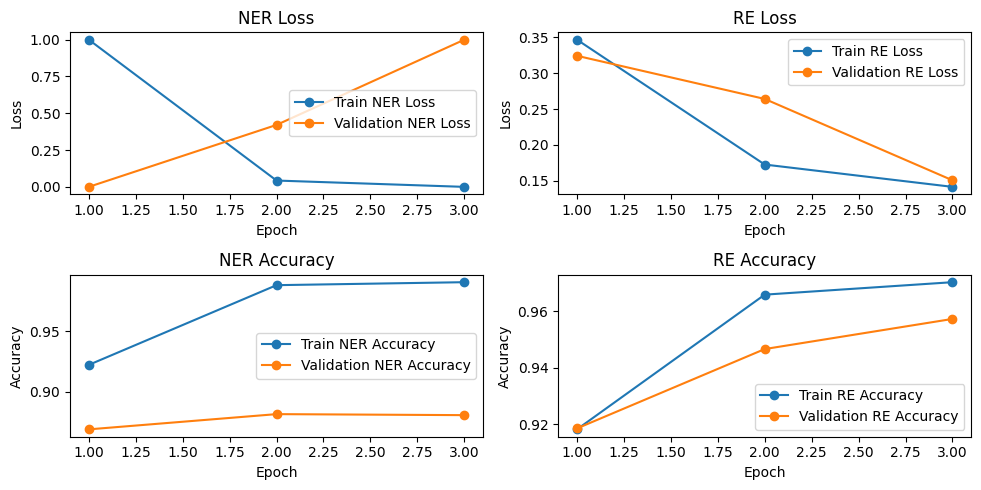

In [74]:
import matplotlib.pyplot as plt

# Data from the training and validation process
epochs = [1, 2, 3]


# Plotting the loss curves
plt.figure(figsize=(10, 5))

# # Plot total loss
# plt.subplot(2, 2, 1)
# plt.plot(epochs, total_train_loss_list, label='Train Total Loss', marker='o')
# plt.plot(epochs, total_val_loss_list, label='Validation Total Loss', marker='o')
# plt.title('Total Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# Plot NER loss
plt.subplot(2, 2, 1)
plt.plot(epochs, ner_loss_list, label='Train NER Loss', marker='o')
plt.plot(epochs, val_ner_loss_list, label='Validation NER Loss', marker='o')
plt.title('NER Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot RE loss
plt.subplot(2, 2, 2)
plt.plot(epochs, re_loss_list, label='Train RE Loss', marker='o')
plt.plot(epochs, val_re_loss_list, label='Validation RE Loss', marker='o')
plt.title('RE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot NER accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, ner_accuracy_list, label='Train NER Accuracy', marker='o')
plt.plot(epochs, val_ner_accuracy_list, label='Validation NER Accuracy', marker='o')
plt.title('NER Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot RE accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, re_accuracy_list, label='Train RE Accuracy', marker='o')
plt.plot(epochs, val_re_accuracy_list, label='Validation RE Accuracy', marker='o')
plt.title('RE Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [75]:
# seqeval already installed
from seqeval.metrics import classification_report as seq_classification_report


In [76]:
# from sklearn.metrics import classification_report

# def evaluate_model_on_test(model, test_dataloader):
#     model.eval()  # Set the model to evaluation mode

#     all_ner_true_labels = []
#     all_ner_predicted_labels = []
#     all_re_true_labels = []
#     all_re_predicted_labels = []

#     with torch.no_grad():  # Disable gradient calculation
#         for batch in test_dataloader:
#             # Unpack the batch
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             entity_mask = batch['entity_mask'].to(device)
#             entity_type_ids = batch['entity_type_ids'].to(device)
#             ner_labels = batch['ner_labels'].to(device)
#             re_labels = batch['re_labels'].to(device)

#             # Forward pass
#             ner_logits, re_logits, _ = model(input_ids, attention_mask, entity_type_ids, entity_mask)

#             # Decode NER predictions
#             predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)

#             # Collect true NER labels and predictions for each batch (ignoring padding tokens)
#             for i in range(len(predicted_ner_labels)):
#                 true_labels = ner_labels[i].cpu().numpy()
#                 # pred_labels = predicted_ner_labels[i]

#                    # Ensure that predicted_ner_labels[i] is a tensor before calling .cpu()
#                 if isinstance(predicted_ner_labels[i], torch.Tensor):
#                     pred_labels = predicted_ner_labels[i].cpu().numpy()
#                 else:
#                     pred_labels = np.array(predicted_ner_labels[i])

#                 # Only consider non-padding tokens for NER accuracy
#                 non_padding_indices = attention_mask[i].cpu().numpy().astype(bool)
#                 # Ensure we are slicing the true and predicted labels correctly
#                 true_labels = true_labels[non_padding_indices]
#                 pred_labels = pred_labels[:len(true_labels)]  # Ensure lengths match

#                 # Extend the true and predicted labels
#                 all_ner_true_labels.extend(true_labels)
#                 all_ner_predicted_labels.extend(pred_labels)

#             # Collect RE true labels and predictions
#             _, predicted_re_labels = torch.max(re_logits, 1)
#             all_re_true_labels.extend(re_labels.cpu().numpy())
#             all_re_predicted_labels.extend(predicted_re_labels.cpu().numpy())

#     # Generate classification reports
#     ner_report = classification_report(all_ner_true_labels, all_ner_predicted_labels, zero_division=0)
#     re_report = classification_report(all_re_true_labels, all_re_predicted_labels, zero_division=0)

#     return ner_report, re_report

from seqeval.metrics import precision_score, recall_score, f1_score, classification_report as ner_classification_report
from sklearn.metrics import classification_report as re_classification_report

import numpy as np

import numpy as np

def evaluate_model_on_test(model, test_dataloader):
    model.eval()  # Set the model to evaluation mode
    all_ner_true_labels = []
    all_ner_predicted_labels = []
    all_re_true_labels = []
    all_re_predicted_labels = []

    with torch.no_grad():
        for batch in test_dataloader:
            # Unpack the batch
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Forward pass
            ner_logits, re_logits, _ = model(input_ids, attention_mask, entity_type_ids, entity_mask)

            # Decode NER predictions using CRF layer
            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)

            # Collect NER true labels and predictions
            for i in range(len(predicted_ner_labels)):
                true_labels = ner_labels[i].cpu().numpy()
                pred_labels = np.array(predicted_ner_labels[i])  # Convert to NumPy array

                # Only consider non-padding tokens for NER accuracy
                valid_token_count = len(pred_labels)
                non_padding_indices = attention_mask[i].cpu().numpy().astype(bool)[:valid_token_count]

                all_ner_true_labels.append([neid2type[label] for label in true_labels[:valid_token_count] if label != 0])
                all_ner_predicted_labels.append([neid2type[label] for label in pred_labels if label != 0])

            # Collect RE true labels and predictions
            _, predicted_re_labels = torch.max(re_logits, 1)
            all_re_true_labels.extend(re_labels.cpu().numpy())
            all_re_predicted_labels.extend(predicted_re_labels.cpu().numpy())

    # Generate classification reports for NER and RE
    ner_report = ner_classification_report(all_ner_true_labels, all_ner_predicted_labels)
    re_report = re_classification_report([reid2type[label] for label in all_re_true_labels],
                                      [reid2type[label] for label in all_re_predicted_labels])

    return ner_report, re_report




In [77]:
# Evaluate the trained model on the test data
ner_report, re_report = evaluate_model_on_test(model, test_dataloader)

# Print the classification reports for NER and RE tasks
print("NER Classification Report:")
print(ner_report)
print("\nRE Classification Report:")
print(re_report)


NER Classification Report:
              precision    recall  f1-score   support

         ACT       0.70      0.65      0.68      5582
         APT       0.78      0.84      0.80      3260
         DOM       0.51      0.41      0.45        49
       EMAIL       0.87      1.00      0.93        20
        ENCR       0.84      0.17      0.29       121
        FILE       0.74      0.70      0.72      1109
        HASH       0.36      0.38      0.37        86
        IDTY       0.68      0.67      0.67      9102
          IP       0.42      0.50      0.46        36
         LOC       0.86      0.91      0.88      4448
         MAL       0.68      0.73      0.70      2932
          OS       0.77      0.67      0.72       343
        PROT       0.03      0.50      0.05         4
     SECTEAM       0.77      0.83      0.80       355
        TIME       0.91      0.83      0.87      1586
        TOOL       0.49      0.37      0.43      2053
         URL       0.25      0.22      0.24         9


c:\CTI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\CTI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\CTI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# Save structured results to JSON for comparison notebook
import json

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        import numpy as np
        if isinstance(obj, (np.integer,)): return int(obj)
        if isinstance(obj, (np.floating,)): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)
from datetime import datetime
from pathlib import Path

# Re-evaluate with output_dict=True
model.eval()
all_ner_true, all_ner_pred = [], []
all_re_true, all_re_pred = [], []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        entity_mask = batch['entity_mask'].to(device)
        entity_type_ids = batch['entity_type_ids'].to(device)
        ner_labels = batch['ner_labels'].to(device)
        re_labels = batch['re_labels'].to(device)

        ner_logits, re_logits, _ = model(input_ids, attention_mask, entity_type_ids, entity_mask)
        predicted_ner = model.decode_ner(ner_logits, attention_mask)

        for i in range(len(predicted_ner)):
            true_l = ner_labels[i].cpu().numpy()
            pred_l = np.array(predicted_ner[i])
            valid = len(pred_l)
            all_ner_true.append([neid2type[l] for l in true_l[:valid] if l != 0])
            all_ner_pred.append([neid2type[l] for l in pred_l if l != 0])

        _, pred_re = torch.max(re_logits, 1)
        all_re_true.extend(re_labels.cpu().numpy().tolist())
        all_re_pred.extend(pred_re.cpu().numpy().tolist())

# NER metrics (seqeval)
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report as ner_cr
ner_dict = ner_cr(all_ner_true, all_ner_pred, output_dict=True)

# RE metrics (sklearn)
from sklearn.metrics import precision_recall_fscore_support, classification_report as re_cr, confusion_matrix
re_true_names = [reid2type[l] for l in all_re_true]
re_pred_names = [reid2type[l] for l in all_re_pred]
re_dict = re_cr(re_true_names, re_pred_names, output_dict=True, zero_division=0)

# --- Compute NER TP/FP/FN per type ---
# seqeval gives support (= TP+FN = gold count), precision, recall per type
# TP = recall * support, FN = support - TP, FP = TP/precision - TP
def compute_counts(d):
    support = d.get("support", 0)
    p = d.get("precision", 0)
    r = d.get("recall", 0)
    tp = round(r * support)
    fn = support - tp
    fp = round(tp / p - tp) if p > 0 else 0
    return tp, fp, fn

# --- Compute RE TP/FP/FN per predicate ---
# sklearn classification_report gives the same: support, precision, recall
# Same derivation works

# Build structured output
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")

# NER results with TP/FP/FN
ner_total_tp, ner_total_fp, ner_total_fn = 0, 0, 0
ner_per_type = {}
for etype in ['APT','MAL','TOOL','ACT','IDTY','LOC','TIME','FILE','SECTEAM',
              'OS','VULID','VULNAME','HASH','DOM','ENCR','IP','URL','PROT','EMAIL']:
    if etype in ner_dict:
        d = ner_dict[etype]
        tp, fp, fn = compute_counts(d)
        ner_total_tp += tp
        ner_total_fp += fp
        ner_total_fn += fn
        ner_per_type[etype] = {
            "precision": d["precision"],
            "recall": d["recall"],
            "f1": d["f1-score"],
            "gold": d["support"],
            "tp": tp,
            "fp": fp,
            "fn": fn,
        }

ner_results = {
    "model": "JE_BERT_CRF",
    "timestamp": timestamp,
    "task": "NER",
    "test_docs": len(test_data),
    "micro": {
        "precision": ner_dict.get("micro avg", {}).get("precision", 0),
        "recall": ner_dict.get("micro avg", {}).get("recall", 0),
        "f1": ner_dict.get("micro avg", {}).get("f1-score", 0),
        "tp": ner_total_tp,
        "fp": ner_total_fp,
        "fn": ner_total_fn,
    },
    "macro": {
        "precision": ner_dict.get("macro avg", {}).get("precision", 0),
        "recall": ner_dict.get("macro avg", {}).get("recall", 0),
        "f1": ner_dict.get("macro avg", {}).get("f1-score", 0),
    },
    "per_type": ner_per_type,
}

# RE results with TP/FP/FN
re_total_tp, re_total_fp, re_total_fn = 0, 0, 0
re_per_pred = {}
for pred_name in ['noRelation','uses','usedBy','targets','targetedBy','affiliatedWith',
                   'associatedWith','identifies','identifiedBy','monitors','monitoredBy',
                   'hasLocation','hasAttackLocation','hasAttackTime','hasVulnerability','contains']:
    if pred_name in re_dict:
        d = re_dict[pred_name]
        tp, fp, fn = compute_counts(d)
        re_total_tp += tp
        re_total_fp += fp
        re_total_fn += fn
        re_per_pred[pred_name] = {
            "precision": d["precision"],
            "recall": d["recall"],
            "f1": d["f1-score"],
            "gold": d["support"],
            "tp": tp,
            "fp": fp,
            "fn": fn,
        }

re_results = {
    "model": "JE_BERT_CRF",
    "timestamp": timestamp,
    "task": "RE",
    "test_docs": len(test_data),
    "micro": {
        "precision": re_dict.get("weighted avg", {}).get("precision", 0),
        "recall": re_dict.get("weighted avg", {}).get("recall", 0),
        "f1": re_dict.get("weighted avg", {}).get("f1-score", 0),
        "tp": re_total_tp,
        "fp": re_total_fp,
        "fn": re_total_fn,
    },
    "macro": {
        "precision": re_dict.get("macro avg", {}).get("precision", 0),
        "recall": re_dict.get("macro avg", {}).get("recall", 0),
        "f1": re_dict.get("macro avg", {}).get("f1-score", 0),
    },
    "per_pred": re_per_pred,
}

# Save
eval_dir = repo_root / "results" / "eval"
eval_dir.mkdir(parents=True, exist_ok=True)

ner_path = eval_dir / f"ner_bert_crf_{timestamp}.json"
re_path = eval_dir / f"re_bert_crf_{timestamp}.json"

with open(ner_path, "w") as f:
    json.dump(ner_results, f, indent=2, cls=NpEncoder)
with open(re_path, "w") as f:
    json.dump(re_results, f, indent=2, cls=NpEncoder)

print(f"Saved: {ner_path.name}")
print(f"Saved: {re_path.name}")
print(f"\nNER micro: P={ner_results['micro']['precision']:.4f} R={ner_results['micro']['recall']:.4f} F1={ner_results['micro']['f1']:.4f}")
print(f"  TP={ner_total_tp} FP={ner_total_fp} FN={ner_total_fn}")
print(f"\nRE  micro: P={re_results['micro']['precision']:.4f} R={re_results['micro']['recall']:.4f} F1={re_results['micro']['f1']:.4f}")
print(f"  TP={re_total_tp} FP={re_total_fp} FN={re_total_fn}")

In [78]:
neid2type

{0: 'null',
 1: 'O',
 2: 'B-APT',
 3: 'I-APT',
 4: 'B-MAL',
 5: 'I-MAL',
 6: 'B-TOOL',
 7: 'I-TOOL',
 8: 'B-ACT',
 9: 'I-ACT',
 10: 'B-IDTY',
 11: 'I-IDTY',
 12: 'B-LOC',
 13: 'I-LOC',
 14: 'B-TIME',
 15: 'I-TIME',
 16: 'B-FILE',
 17: 'I-FILE',
 18: 'B-SECTEAM',
 19: 'I-SECTEAM',
 20: 'B-OS',
 21: 'I-OS',
 22: 'B-VULID',
 23: 'I-VULID',
 24: 'B-VULNAME',
 25: 'I-VULNAME',
 26: 'B-HASH',
 27: 'I-HASH',
 28: 'B-DOM',
 29: 'I-DOM',
 30: 'B-ENCR',
 31: 'I-ENCR',
 32: 'B-IP',
 33: 'I-IP',
 34: 'B-URL',
 35: 'I-URL',
 36: 'B-PROT',
 37: 'I-PROT',
 38: 'B-EMAIL',
 39: 'I-EMAIL'}

In [79]:
# Old debug cell — skipped (model test already done in cell 49)
pass

In [80]:
2 + 2

4